# 🌱 Suitability Modelling Steps

## 1️⃣ Define target species
- We write down the list of species we want to model.

## 2️⃣ Download and clean occurrences
- For each species:
  - We download occurrence points (e.g., from GBIF).
  - We clean the data:
    - Remove invalid or missing coordinates.
    - Remove points over the ocean.
    - Remove duplicates.
    - Optionally, filter to recent years.
- We save the cleaned occurrences as a dataframe with:  
  `species, lon, lat`.

## 3️⃣ Generate background (pseudo-absence) points
- We create random points across the study area.
- We assign them `presence = 0`.

## 4️⃣ Load environmental predictors
- We choose our predictors:
  - TerraClimate (monthly & flexible)  
  - or WorldClim (BIO1–BIO19, easy for SDMs).
- We load the raster files into Python.
- We stack them into a single dataset.

## 5️⃣ Extract predictor values at points
- At occurrence and background points, we extract the predictor values from the rasters.
- We combine everything into one dataframe with predictors + `presence` column.

## 6️⃣ Train a model per species
- For each species:
  - We fit a model using predictors and `presence`.
  - Example models:
    - Logistic regression
    - Random forest
    - Gradient boosting
    - Ensemble

## 7️⃣ Predict suitability over study area
- We use the trained model to predict suitability across the full raster grid.

## 8️⃣ Save and analyse results
- We save the predicted suitability map (e.g., GeoTIFF).
- Optionally:
  - We visualise the maps.
  - We overlay maps of multiple species.
  - We compute statistics like total suitable area, overlap, etc.


## 1️⃣ Define target species
let's for now just use those examples from the bachelor thesis


In [1]:
from utils_agroforestry import *
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Load agroforestry composition tables
agroforest = {
    0: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv"),
    1: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv"),
}


In [2]:
import pandas as pd

# ✅ Step 1: Define target species
# Assuming these are your two dataframes with species of interest:
# df1 and df2 already loaded

target_species = pd.concat([agroforest[0]['species'], agroforest[1]['species']]).dropna().unique()
print(f"🎯 Found {len(target_species)} target species.")



🎯 Found 50 target species.


In [3]:
agroforest[0][agroforest[0].type=="1st tree"]

,species,type,cover_ratio,quantity,height_min_m,height_max_m
0,Inga Fagifolia,1st tree,20.0,43,5.0,25.0
1,Mangifera Indica,1st tree,5.0,22,5.0,25.0
2,Roystonea Hispaniolana,1st tree,1.0,6,5.0,25.0
3,Didymopanax Morototoni,1st tree,1.0,5,5.0,25.0
4,Senna Spectabilis,1st tree,0.5,2,5.0,25.0


In [4]:
import pandas as pd
import numpy as np

# 📋 Step 1: Define target species
# Assuming agroforest[0] is already loaded and is a DataFrame

# 🎯 Filter species where type == '1st tree'
target_species_df = agroforest[0][agroforest[0].type == "1st tree"].dropna(subset=["species"])

# 🎯 Get unique species names
target_species = np.unique(target_species_df["species"])

# 📋 Ensure coffee and cacao are included
target_species = list(target_species)
if "Theobroma cacao" not in target_species:
    target_species.append("Theobroma cacao")
if "Coffea arabica" not in target_species:
    target_species.append("Coffea arabica")

target_species = np.unique(target_species)  # back to sorted, unique array

print(f"🎯 Final list of target species: {len(target_species)} species")
print(target_species)


🎯 Final list of target species: 7 species
['Coffea arabica' 'Didymopanax Morototoni  ' 'Inga Fagifolia  '
 'Mangifera Indica  ' 'Roystonea Hispaniolana  ' 'Senna Spectabilis  '
 'Theobroma cacao']


In [31]:
import pandas as pd
from utils_suitability_modelling import (
    clean_species_name, fetch_gbif_species, load_existing
)

# 🎯 Ensure target_species is cleaned & unique
target_species_clean = sorted({clean_species_name(s) for s in target_species})
print(f"🎯 Target species ({len(target_species_clean)}): {target_species_clean}")

# 📋 Bounding box
wkt_bbox = "POLYGON((-100 10, -77 10, -77 22, -100 22, -100 10))"

# 📋 Load existing GBIF
occ_raw, already_fetched = load_existing()

# 📋 Load Excel
excel_path = "/Users/szelie/data/unu/occurrence_data-1.xlsx"
df_excel = pd.read_excel(excel_path, sheet_name="Data")

# 🧹 Clean Excel & filter
df_excel = df_excel.rename(columns={
    "species": "species_query",
    "lon": "decimalLongitude",
    "lat": "decimalLatitude"
})
df_excel["species_query"] = df_excel["species_query"].apply(clean_species_name)
df_excel = df_excel[df_excel["species_query"].isin(target_species_clean)]

print(f"✅ Excel: {len(df_excel)} records for target species.")

# 📋 Fetch GBIF for missing species
for species in target_species_clean:
    if species in already_fetched:
        print(f"✅ Already fetched: {species}, skipping.")
        continue

    print(f"🌱 Fetching GBIF: {species}")
    try:
        records = fetch_gbif_species(species, wkt_bbox)
        if not records.empty:
            records["species_query"] = species
            occ_raw = pd.concat([occ_raw, records], ignore_index=True)
            occ_raw.to_parquet("occurrences_raw.parquet", index=False)
            already_fetched.add(species)
            print(f"💾 Progress: {len(already_fetched)} species saved.")
        else:
            print(f"⚠️ No results for: {species}")
    except Exception as e:
        print(f"❌ Failed for {species}: {e}")

# 🧹 Clean & filter GBIF
occ_raw["species_query"] = occ_raw["species_query"].apply(clean_species_name)
occ_raw = occ_raw[occ_raw["species_query"].isin(target_species_clean)]

print(f"✅ GBIF: {len(occ_raw)} records for target species.")

# 📋 Keep only necessary columns
df_gbif = occ_raw[["species_query", "decimalLongitude", "decimalLatitude"]].copy()

# 📋 Combine Excel + GBIF & deduplicate
print(np.unique(df_excel[df_excel["species_query"].isin(target_species_clean)].species_query))
combined = pd.concat([df_gbif, df_excel], ignore_index=True)
before = len(combined)
combined = combined.drop_duplicates(subset=["species_query", "decimalLongitude", "decimalLatitude"])
after = len(combined)

# 🔷 Sanity check: ensure only target_species remain
invalid_species = set(combined["species_query"]) - set(target_species_clean)
if invalid_species:
    print(f"⚠️ Unexpected species found & removed: {invalid_species}")
    combined = combined[combined["species_query"].isin(target_species_clean)]

print(f"\n🎉 Final dataset: {after} records ({before-after} duplicates removed).")

# 📋 Save
if os.path.exists("occurrences_combined.parquet"):
    os.remove("occurrences_combined.parquet")
combined.to_parquet("occurrences_combined.parquet", index=False)
print(f"💾 Saved: occurrences_combined.parquet")


🎯 Target species (7): ['Coffea arabica', 'Didymopanax morototoni', 'Inga fagifolia', 'Mangifera indica', 'Roystonea hispaniolana', 'Senna spectabilis', 'Theobroma cacao']
📄 Loaded 41 species from occurrences_raw.parquet
✅ Excel: 2588 records for target species.
✅ Already fetched: Coffea arabica, skipping.
✅ Already fetched: Didymopanax morototoni, skipping.
🌱 Fetching GBIF: Inga fagifolia
⚠️ No results for: Inga fagifolia
✅ Already fetched: Mangifera indica, skipping.
✅ Already fetched: Roystonea hispaniolana, skipping.
✅ Already fetched: Senna spectabilis, skipping.
✅ Already fetched: Theobroma cacao, skipping.
✅ GBIF: 2853 records for target species.
['Coffea arabica' 'Mangifera indica' 'Theobroma cacao']

🎉 Final dataset: 4446 records (995 duplicates removed).
💾 Saved: occurrences_combined.parquet


In [32]:
np.unique(combined.species_query)

array(['Coffea arabica', 'Didymopanax morototoni', 'Mangifera indica',
       'Roystonea hispaniolana', 'Senna spectabilis', 'Theobroma cacao'],
      dtype=object)

## 2️⃣ Load and clean occurrences

This step constructs a **clean, deduplicated dataset of species occurrence records** for suitability modelling.  
It combines multiple complementary data sources and applies quality filters to ensure consistency and reliability.

---

### 📂 Data sources used in this step:
We currently combine two complementary datasets:

### 1️⃣ **GBIF records**
- Fetched via the `pygbif` library from the **Global Biodiversity Information Facility (GBIF)**.
- Filters applied:
  - valid coordinates (`hasCoordinate = True`)
  - records within a defined **Central America bounding box** (`wkt_bbox`)
  - records collected **after 1960** (to align with the climate data baseline).
- Skips already-fetched species (if present in an existing `occurrences_raw.parquet`) to save time.
- Saves intermediate results after each species.

### 2️⃣ **Curated data from de Sousa et al. (2019)**
- Loads an **Excel file (`occurrence_data-1.xlsx`)**, which contains the curated presence locations from:
  > de Sousa, K., van Zonneveld, M., Holmgren, M. et al.  
  > *The future of coffee and cocoa agroforestry in a warmer Mesoamerica.*  
  > *Scientific Reports* 9, 8828 (2019).  
  > [https://doi.org/10.1038/s41598-019-45491-7](https://doi.org/10.1038/s41598-019-45491-7)

- This dataset includes validated locations for coffee, cocoa, and associated agroforestry species, compiled from inventories, field observations, and expert knowledge.
- This data is higher quality than GBIF alone and fills gaps where GBIF coverage is poor.

---

### 🔗 **Combining the datasets**
- Concatenates GBIF and Excel records.
- Removes duplicates based on `species_query`, `decimalLongitude`, and `decimalLatitude`.
- Saves the resulting clean dataset as `occurrences_combined.parquet`.

---

### 🚨 Why some GBIF observations are lost
The strict filters (post-1960, valid coordinates, within study region) remove a significant number of GBIF records.  
This prioritises data quality and alignment with the study’s climate baseline, at the cost of quantity.

Since the **Excel file already contains curated data from the de Sousa et al. (2019) paper**, the loss of some GBIF records is acceptable and expected.

---

### 📈 Summary
✅ Fetch GBIF data (filtered & standardised)  
✅ Load curated presence locations from the de Sousa et al. (2019) Excel dataset  
✅ Combine, deduplicate, and save the clean dataset  
🔷 Final dataset combines GBIF observations and validated published data for robust suitability modelling.


In [7]:
import pandas as pd
from utils_suitability_modelling import (
    clean_species_name, fetch_gbif_species, load_existing
)

# 📋 Inputs
wkt_bbox = "POLYGON((-100 10, -77 10, -77 22, -100 22, -100 10))"
excel_path = "/Users/szelie/data/unu/occurrence_data-1.xlsx"

# 📋 Load existing GBIF data
occ_raw, already_fetched = load_existing()

# 📋 Fetch GBIF data for each species
for species_raw in target_species:
    species = clean_species_name(species_raw)
    if species in already_fetched:
        print(f"✅ Already fetched: {species}, skipping.")
        continue

    print(f"🌱 Fetching: {species}")
    try:
        records = fetch_gbif_species(species, wkt_bbox)
        if not records.empty:
            records["species_query"] = species
            occ_raw = pd.concat([occ_raw, records], ignore_index=True)
            occ_raw.to_parquet("occurrences_raw.parquet", index=False)
            already_fetched.add(species)
            print(f"💾 Saved progress: {len(already_fetched)} species so far.")
        else:
            print(f"⚠️ No results for: {species}")
    except Exception as e:
        print(f"❌ Failed for {species}: {e}")

print(f"\n✅ Downloaded total: {len(occ_raw)} GBIF records.")

# 📋 Load Excel data
df_excel = pd.read_excel(excel_path, sheet_name="Data")
df_excel = df_excel.rename(columns={
    "species": "species_query",
    "lon": "decimalLongitude",
    "lat": "decimalLatitude"
})

print(f"✅ Loaded {len(df_excel)} records from Excel.")

# 📋 Combine & deduplicate
combined = pd.concat([occ_raw, df_excel], ignore_index=True)
combined = combined.drop_duplicates(
    subset=["species_query", "decimalLongitude", "decimalLatitude"]
)

print(f"🎉 Combined dataset: {len(combined)} records.")

# 📋 Keep only relevant columns & rename
combined_clean = combined[["species_query", "decimalLongitude", "decimalLatitude"]].copy()
combined_clean = combined_clean.rename(columns={
    "species_query": "species",
    "decimalLongitude": "lon",
    "decimalLatitude": "lat"
})
combined_clean["presence"] = 1  # mark all as presence

# 📋 Save minimal clean dataset
combined_clean.to_parquet("occurrences_combined.parquet", index=False)
print(f"💾 Saved clean dataset to 'occurrences_combined_clean.parquet'")

combined_clean.head()


📄 Loaded 41 species from occurrences_raw.parquet
✅ Already fetched: Coffea arabica, skipping.
✅ Already fetched: Didymopanax morototoni, skipping.
🌱 Fetching: Inga fagifolia
⚠️ No results for: Inga fagifolia
✅ Already fetched: Mangifera indica, skipping.
✅ Already fetched: Roystonea hispaniolana, skipping.
✅ Already fetched: Senna spectabilis, skipping.
✅ Already fetched: Theobroma cacao, skipping.

✅ Downloaded total: 12998 GBIF records.
✅ Loaded 136903 records from Excel.
🎉 Combined dataset: 147990 records.
💾 Saved clean dataset to 'occurrences_combined_clean.parquet'


,species,lon,lat,presence
0,Mangifera indica,177.160220,-17.758151,1
1,Mangifera indica,120.401191,16.802241,1
2,Mangifera indica,-80.163445,26.976393,1
3,Mangifera indica,-158.155548,21.485985,1
4,Mangifera indica,-158.155545,21.486024,1


In [8]:
combined_clean

,species,lon,lat,presence
0,Mangifera indica,177.160220,-17.758151,1
1,Mangifera indica,120.401191,16.802241,1
2,Mangifera indica,-80.163445,26.976393,1
3,Mangifera indica,-158.155548,21.485985,1
4,Mangifera indica,-158.155545,21.486024,1
...,...,...,...,...
149891,Coffea arabica,-84.030000,9.760000,1
149892,Coffea arabica,-84.260000,9.900000,1
149893,Coffea arabica,-87.040000,5.550000,1
149899,Coffea arabica,-84.260000,9.910000,1


## 📍 Visualising Occurrence Points and Study Area

In this step, we plot the occurrence points (both all records and those within the study area)  
and the bounding box defining the study area.

The study area is defined as a slightly **larger bounding box** than the strict region of interest (Mexico + Guatemala + Dominican Republic)  
to include more occurrence points that are ecologically relevant but might otherwise fall just outside the strict borders.  
This helps to mitigate sparse data issues and avoid excluding potentially informative presence locations.

We compare:
- all occurrence records (grey)
- occurrence records inside the study area (red)
- the study area boundary (blue)

This helps check whether the chosen study area captures a sufficient number of points
,

✅ All records: 4446
✅ In study area: 2868


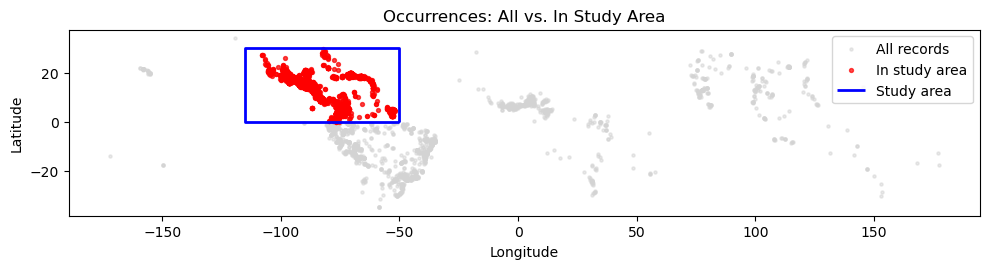

In [33]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

# 📂 Load clean occurrence data
occ_all = pd.read_parquet("occurrences_combined.parquet")

# 🧹 Ensure columns are properly named
if {"lon", "lat"}.issubset(occ_all.columns):
    pass
elif {"decimalLongitude", "decimalLatitude"}.issubset(occ_all.columns):
    occ_all = occ_all.rename(columns={
        "decimalLongitude": "lon",
        "decimalLatitude": "lat"
    })
else:
    raise ValueError(f"🚨 Could not find coordinates columns in: {list(occ_all.columns)}")

if "species_query" in occ_all.columns:
    occ_all = occ_all.rename(columns={"species_query": "species"})

# 📋 Keep only needed columns
occ_all = occ_all[["species", "lon", "lat"]].copy()

# 📍 Define study area bounding box
lon_min, lon_max = -115, -50
lat_min, lat_max = 0, 30

# 🎯 Filter occurrences inside the study area
occ_study_area = occ_all[
    (occ_all['lon'] >= lon_min) & (occ_all['lon'] <= lon_max) &
    (occ_all['lat'] >= lat_min) & (occ_all['lat'] <= lat_max)
].copy()

print(f"✅ All records: {len(occ_all)}")
print(f"✅ In study area: {len(occ_study_area)}")

# 🔷 Create GeoDataFrames
gdf_all = gpd.GeoDataFrame(
    occ_all,
    geometry=gpd.points_from_xy(occ_all.lon, occ_all.lat),
    crs="EPSG:4326"
)

gdf_study = gpd.GeoDataFrame(
    occ_study_area,
    geometry=gpd.points_from_xy(occ_study_area.lon, occ_study_area.lat),
    crs="EPSG:4326"
)

# 🔷 Define study area polygon
study_area_poly = box(lon_min, lat_min, lon_max, lat_max)

# 🗺️ Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf_all.plot(ax=ax, color="lightgray", label="All records", alpha=0.5, markersize=5)
gdf_study.plot(ax=ax, color="red", label="In study area", alpha=0.7, markersize=8)

# Plot bounding box
gpd.GeoSeries([study_area_poly], crs="EPSG:4326").boundary.plot(
    ax=ax, color="blue", linewidth=2, label="Study area"
)

ax.set_title("Occurrences: All vs. In Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
np.unique(occ_raw.species_query)

array(['Coffea arabica', 'Didymopanax morototoni', 'Mangifera indica',
       'Roystonea hispaniolana', 'Senna spectabilis', 'Theobroma cacao'],
      dtype=object)

## 📋 Generating Background (Pseudo-absence) Points

This step generates a **general pool of random background points** within the study area bounding box.  
These points represent locations where the species **is assumed absent** and are commonly used in presence–background or presence–pseudoabsence models (e.g., MaxEnt, Random Forest).

---

### 📂 What happens in this step?
✅ Defines a **bounding box** covering Mexico, Guatemala, and the Dominican Republic:
- Longitude: `-100.98` to `-77.02`
- Latitude: `13` to `21.98`

✅ Generates a fixed number of random points (`n_background = 5000`) uniformly distributed within this box:
- Each point is assigned:
  - a random longitude within `lon_min … lon_max`
  - a random latitude within `lat_min … lat_max`
  - a label `presence = 0` indicating it is a background point (not observed as presence).

✅ Creates a `pandas.DataFrame` of these points with columns:
| lon | lat | presence |
|-----|-----|----------|

✅ Sets a random seed (`seed=42`) for reproducibility — ensures the same random points are generated each time the code runs.

---

### 📈 Why do we need background points?
In species distribution modelling, you often only know where the species was observed (**presence-only data**) but have no confirmed absence data.  
To estimate suitability, you compare environmental conditions at presence locations with those at random (background) locations.  
These background points act as a proxy for the available environmental conditions in the study area.

---

### 📋 Selecting background points per species
At this stage, we generate a **general pool of background points for the whole study area**.  
Later, during model training for a specific species, we can:
- sample a subset of these points (e.g., equal to or 5× the number of presence points),
- optionally filter to ensure they are far enough away from presence points for that species,
- or apply other species-specific criteria.

This design allows the same general pool to be reused consistently across species.

---

### 📄 Output
- A table of ~5000 random points within the study area.
- Each point is labelled as `presence = 0` (pseudo-absence).
- Ready for further processing (e.g., extracting bioclimatic variables, sampling per species).

---

### 📌 Summary
✅ Define study area bounding box  
✅ Generate a general pool of random background points  
✅ Label them as absence (`presence = 0`)  
✅ Later: filter or sample these points when training models for each species.


In [11]:
from utils_suitability_modelling import generate_background_points

# 📍 Define study area (Mexico + Guatemala + DR)
lon_min, lon_max = -100.98, -77.02
lat_min, lat_max = 13, 21.98

# 🎯 Number of background points
n_background = 1000

# 📋 Generate background points
background = generate_background_points(lon_min, lon_max, lat_min, lat_max, n_background)

background.head()


✅ Generated 1000 background points.


,lon,lat,presence
0,-92.006019,14.662494,0
1,-78.200885,17.866271,0
2,-83.441425,20.839054,0
3,-86.636143,19.575379,0
4,-97.241793,20.242919,0


## 4️⃣ Load environmental predictors
- We choose our predictors:
  - TerraClimate (monthly & flexible)  
  - or WorldClim (BIO1–BIO19, easy for SDMs).
- We load the raster files into Python.
- We stack them into a single dataset.



### Why WorldClim?
We use WorldClim because:
- it provides globally consistent, high-resolution climate data,
- the bioclimatic variables summarise ecologically meaningful climate gradients (annual trends, seasonality, extremes),
- they are designed specifically for ecological and species distribution modelling (SDM),
- the baseline period (~1960–1990) aligns with many published studies.

These layers capture the climatic niche of species and are a standard input in SDM studies.


In [35]:
import glob
import rioxarray as rxr
import xarray as xr

# 🌏 your folder with all 19 BIO files
raster_dir = "/Users/szelie/data/unu/wc2-2"

# 📂 find all .tif files for BIO variables
raster_files = sorted(glob.glob(f"{raster_dir}/wc2.1_2.5m_bio_*.tif"))

print(f"🗺️ Found {len(raster_files)} raster layers.")
assert len(raster_files) == 19, "Expected 19 BIO layers."

# 📦 load and stack
bio_layers = [rxr.open_rasterio(f, masked=True).squeeze() for f in raster_files]

# name each layer BIO1 … BIO19
for i, da in enumerate(bio_layers, 1):
    da.name = f"BIO{i}"

# merge into single xarray.Dataset
bio_stack = xr.merge(bio_layers)

print(bio_stack)

# optional: save as NetCDF if you want
# bio_stack.to_netcdf("/Users/szelie/data/unu/worldclim_bio_stack.nc")


🗺️ Found 19 raster layers.
<xarray.Dataset> Size: 3GB
Dimensions:      (x: 8640, y: 4320)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
    spatial_ref  int64 8B 0
Data variables: (12/19)
    BIO1         (y, x) float32 149MB ...
    BIO2         (y, x) float32 149MB ...
    BIO3         (y, x) float32 149MB ...
    BIO4         (y, x) float32 149MB ...
    BIO5         (y, x) float32 149MB ...
    BIO6         (y, x) float32 149MB ...
    ...           ...
    BIO14        (y, x) float32 149MB ...
    BIO15        (y, x) float32 149MB ...
    BIO16        (y, x) float32 149MB ...
    BIO17        (y, x) float32 149MB ...
    BIO18        (y, x) float32 149MB ...
    BIO19        (y, x) float32 149MB ...
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMU

## 5️⃣ Extract predictor values at points
- At occurrence and background points, we extract the predictor values from the rasters.
- We combine everything into one dataframe with predictors + `presence` column.

In [36]:
from utils_suitability_modelling import build_training_dataset

# 📋 Inputs
bbox = (-100.98, -77.02, 13, 21.98)
selected_predictors = [
    "BIO2", "BIO3", "BIO8", "BIO9",
    "BIO13", "BIO14", "BIO15", "BIO18", "BIO19"
]

# 📂 Run
data_all = build_training_dataset(
    presence_df=occ_all,          # your simplified df with ['species', 'lon', 'lat']
    bio_stack=bio_stack,            # the xarray Dataset of bioclim layers
    bbox=bbox,
    selected_predictors=selected_predictors,
    background_ratio=5
)

data_all.head()


✅ Found 1247 presence points in study area.
🚀 Querying predictors for 7482 points…
🎉 Final dataset: 3690 records.
presence
0    2445
1    1245
Name: count, dtype: int64
species
background           2445
Coffea arabica        904
Mangifera indica      181
Theobroma cacao       153
Senna spectabilis       7
Name: count, dtype: int64


,BIO2,BIO3,BIO8,BIO9,BIO13,BIO14,BIO15,BIO18,BIO19,lon,lat,presence,species
0,27.459999,23.440666,587.0,113.0,68.643631,172.217117,33.152000,27.357334,25.228666,-88.563708,18.074789,1,Mangifera indica
1,27.459999,23.440666,587.0,113.0,68.643631,172.217117,33.152000,27.357334,25.228666,-88.562892,18.073619,1,Mangifera indica
2,27.832666,22.950001,467.0,76.0,67.493713,202.527802,35.751999,27.112665,25.290667,-89.200853,20.876713,1,Mangifera indica
3,26.454666,22.469334,766.0,170.0,64.459419,169.866043,31.628000,26.189333,24.232000,-88.667117,17.106394,1,Mangifera indica
4,28.744118,25.320589,1115.0,255.0,63.324554,148.776718,32.058823,26.299019,27.807842,-86.572840,16.323948,1,Mangifera indica


In [37]:
np.unique(data_all.species)

array(['Coffea arabica', 'Mangifera indica', 'Senna spectabilis',
       'Theobroma cacao', 'background'], dtype=object)

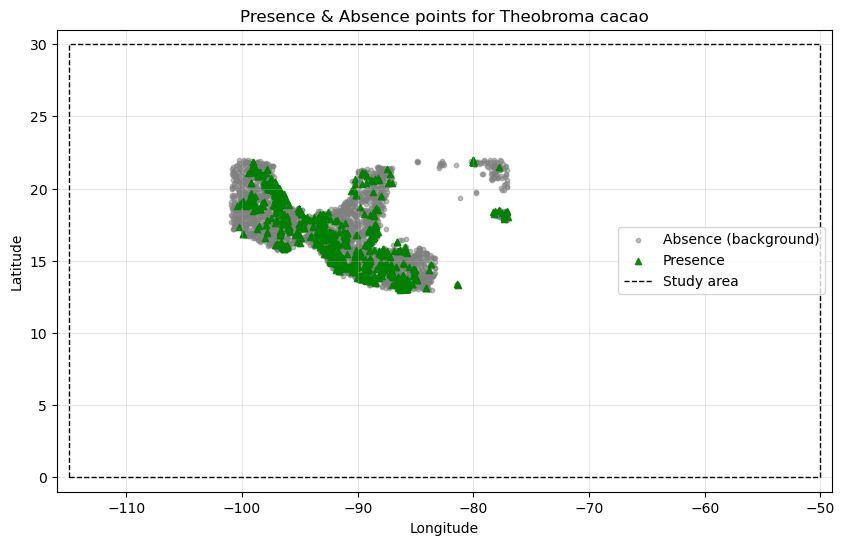

In [38]:
import matplotlib.pyplot as plt

# 📋 Separate presence & absence
presences = data_all[data_all["presence"] == 1]
absences  = data_all[data_all["presence"] == 0]

plt.figure(figsize=(10, 6))

# Background points (absence)
plt.scatter(
    absences["lon"], absences["lat"],
    color="grey", alpha=0.5, s=10, label="Absence (background)"
)

# Presence points
plt.scatter(
    presences["lon"], presences["lat"],
    color="green", alpha=0.9, s=20, marker='^', label="Presence"
)

# Study area bbox
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color="black", linestyle="--", linewidth=1, label="Study area"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Presence & Absence points for {species}")
plt.legend()
plt.xlim(lon_min - 1, lon_max + 1)
plt.ylim(lat_min - 1, lat_max + 1)
plt.grid(True, alpha=0.3)
plt.show()


## 🌳 Random Forest suitability model for any species

This cell trains and evaluates a Random Forest classifier to model the climatic suitability of a selected species based on bioclimatic predictors.  
By changing the `species` variable at the top of the cell, the workflow can be applied to any species present in the dataset.

### Steps:
- Set the `species` name (e.g., *Theobroma cacao*), and filter the dataset to keep only presence points for this species and candidate background (absence) points.
- Use a KDTree to ensure selected background points are at least 0.5° (~10 km) away from any presence point, reducing spatial bias.
- Combine presence and selected background points into one dataset.
- Split the data into training (70%) and testing (30%) sets while preserving the class distribution (stratified).
- Train a Random Forest classifier with 100 trees on the training set.
- Evaluate model performance on the test set using the Area Under the ROC Curve (AUC).
- Plot feature importances to identify the most influential bioclimatic variables.
- Display a confusion matrix to summarise classification performance.

This provides a flexible and robust baseline model for species distribution modelling using presence–background data, adaptable to any species of interest.



🌱 Training model for: Mangifera indica (181 presence points)
🌳 AUC for Mangifera indica: 0.774
⚠️ Too few presence points for Senna spectabilis (7), skipping.

🌱 Training model for: Theobroma cacao (153 presence points)
🌳 AUC for Theobroma cacao: 0.852


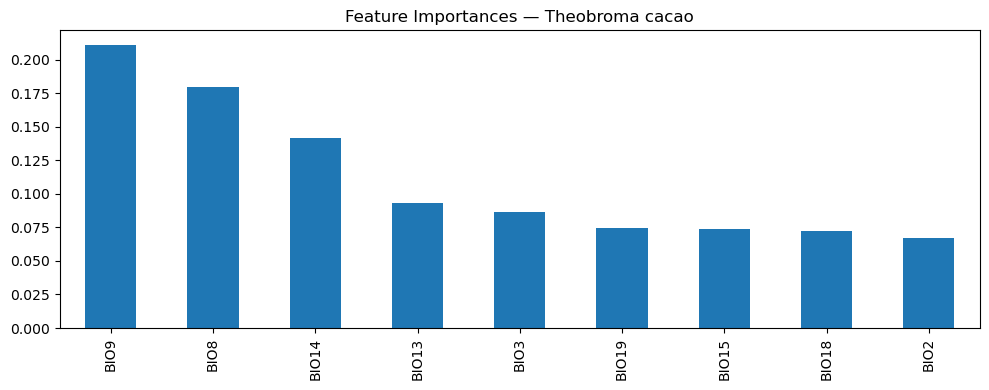

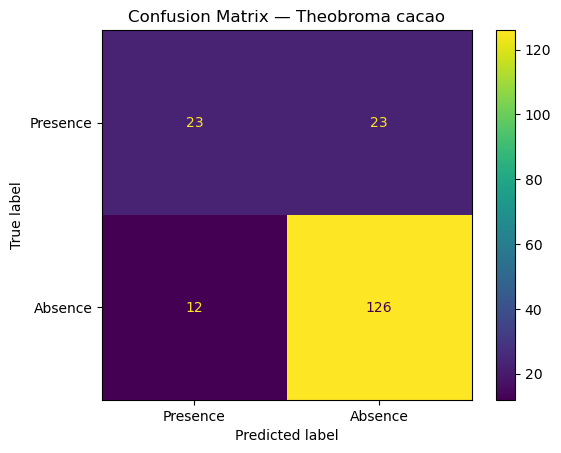


🌱 Training model for: Coffea arabica (904 presence points)
🌳 AUC for Coffea arabica: 0.913


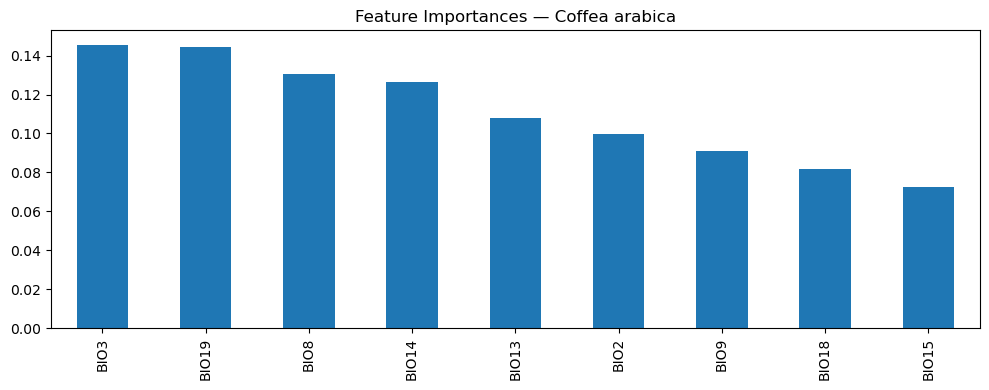

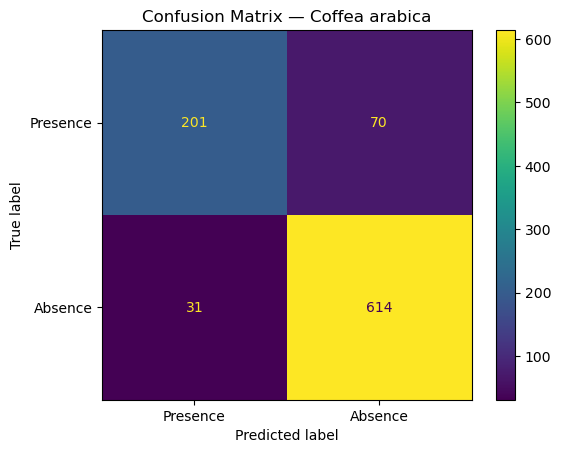

⚠️ Too few presence points for background (0), skipping.

🎉 AUC summary for all species:
Mangifera indica: 0.774
Theobroma cacao: 0.852
Coffea arabica: 0.913


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 📋 Select predictors
selected_predictors = ["BIO2", "BIO3", "BIO8", "BIO9", "BIO13", "BIO14", "BIO15", "BIO18", "BIO19"]
min_distance_deg = 0.1
species_to_plot = ["Coffea arabica", "Theobroma cacao"]

# 📋 Prepare cleaned data
if {"lon", "lat"}.issubset(data_all.columns):
    keep_cols = ["lon", "lat"] + selected_predictors + ["presence", "species"]
else:
    keep_cols = ["decimalLongitude", "decimalLatitude"] + selected_predictors + ["presence", "species"]
    data_all = data_all.rename(columns={"decimalLongitude": "lon", "decimalLatitude": "lat"})

data_clean = data_all[keep_cols].copy()

# 📋 Prepare results containers
auc_results = {}
trained_classifiers = {}
feature_columns = {}

# 🚀 Loop over all species with presence points
for species in data_clean["species"].unique():
    df_presence = data_clean[(data_clean["species"] == species) & (data_clean["presence"] == 1)].copy()
    df_background_candidates = data_clean[data_clean["presence"] == 0].copy()

    if len(df_presence) < 10:
        print(f"⚠️ Too few presence points for {species} ({len(df_presence)}), skipping.")
        continue

    print(f"\n🌱 Training model for: {species} ({len(df_presence)} presence points)")

    # 📄 Build KDTree of presence points
    presence_coords = df_presence[["lon", "lat"]].to_numpy()
    tree = cKDTree(presence_coords)

    # 📋 Sample background points far enough from presences
    n_background = min(len(df_presence) * 3, len(df_background_candidates))
    np.random.seed(42)

    bg_selected = []
    for _, row in df_background_candidates.sample(frac=1, random_state=42).iterrows():
        lon, lat = row["lon"], row["lat"]
        dist, _ = tree.query([lon, lat], k=1)
        if dist >= min_distance_deg:
            bg_selected.append(row)
        if len(bg_selected) >= n_background:
            break

    if len(bg_selected) < 10:
        print(f"⚠️ Too few valid background points for {species}, skipping.")
        continue

    df_background = pd.DataFrame(bg_selected).copy()
    df_background["species"] = species

    # 📋 Combine
    df = pd.concat([df_presence, df_background], ignore_index=True)

    if df["presence"].nunique() < 2:
        print(f"🚨 Only one class present for {species}. Skipping.")
        continue

    X = df.drop(columns=["species", "presence", "lon", "lat"])
    y = df["presence"]

    # Save feature columns
    feature_columns[species] = list(X.columns)

    # 🚂 Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    trained_classifiers[species] = clf

    y_pred = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    auc_results[species] = auc

    print(f"🌳 AUC for {species}: {auc:.3f}")

    # 📊 Optionally plot for key species
    if species in species_to_plot:
        # 📋 Feature importances
        importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

        importances.plot(kind="bar", figsize=(10,4), title=f"Feature Importances — {species}")
        plt.tight_layout()
        plt.show()

        y_pred_label = (y_pred > 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred_label, labels=[1,0])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Presence", "Absence"])
        disp.plot()
        plt.title(f"Confusion Matrix — {species}")
        plt.show()

# 📄 Summary
print("\n🎉 AUC summary for all species:")
for k, v in auc_results.items():
    print(f"{k}: {v:.3f}")


In [81]:
data_clean["species"].unique()

array(['Mangifera indica', 'Senna spectabilis', 'Theobroma cacao',
       'Coffea arabica', 'background'], dtype=object)

✅ Valid grid points in study area: 48004

🌱 Predicting suitability for: Mangifera indica


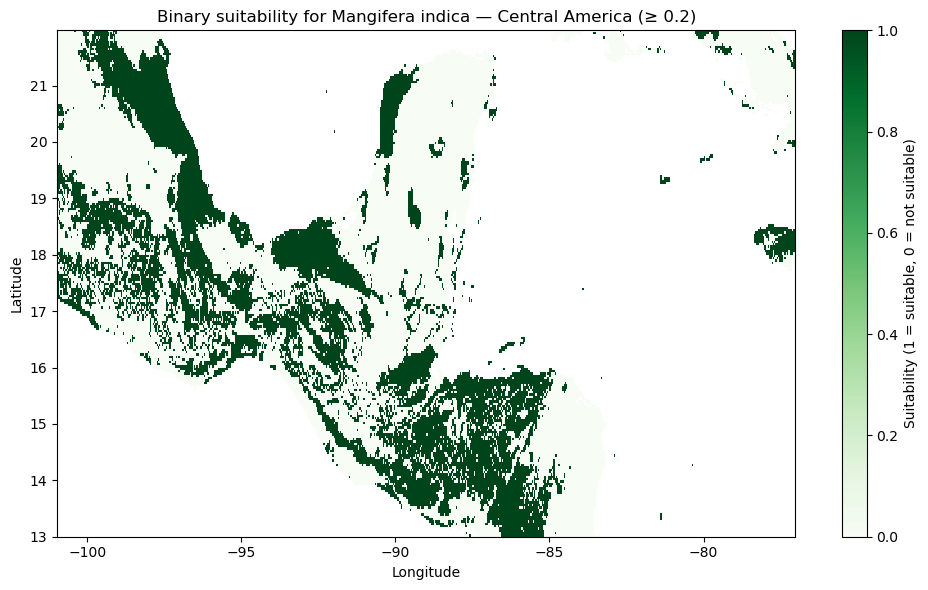


🌱 Predicting suitability for: Theobroma cacao


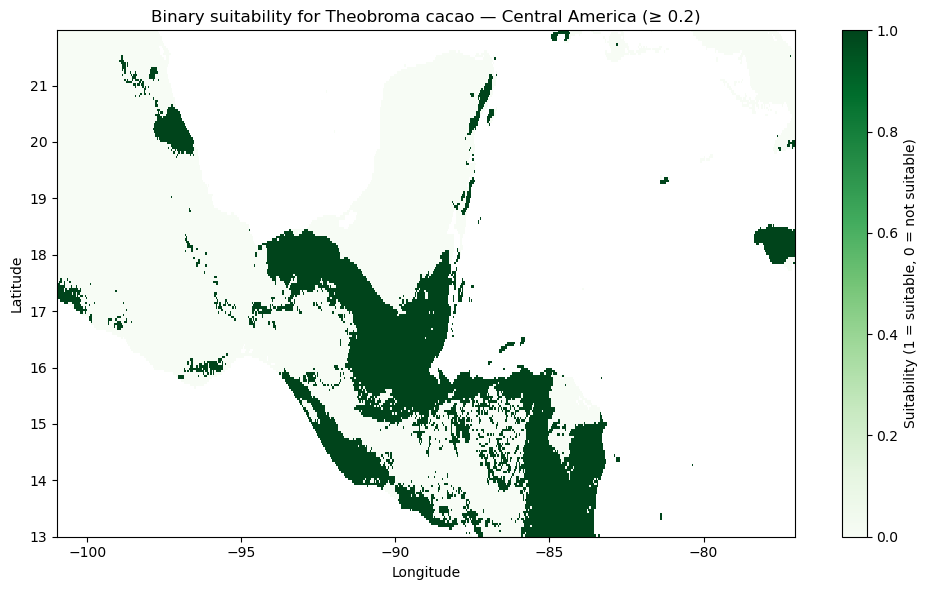


🌱 Predicting suitability for: Coffea arabica


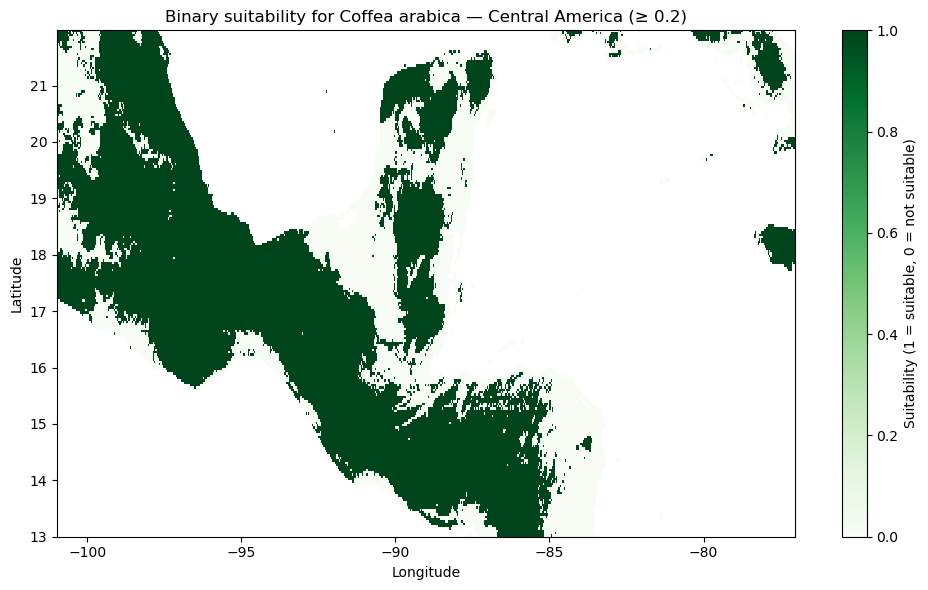

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📋 Define study area bounding box
lon_min, lon_max = -100.98, -77.02
lat_min, lat_max = 13, 21.98

# 📋 Create prediction grid from bio_stack
xv, yv = np.meshgrid(bio_stack.x.values, bio_stack.y.values)

grid_df = pd.DataFrame({
    'lon': xv.ravel(),
    'lat': yv.ravel()
})

# Add BIO variables to grid
for var in bio_stack.data_vars:
    grid_df[var] = bio_stack[var].values.ravel()

# Drop rows with missing data (e.g., oceans)
valid_grid_df = grid_df.dropna()

# 📋 Filter grid to study area
valid_grid_df = valid_grid_df[
    (valid_grid_df['lon'] >= lon_min) & (valid_grid_df['lon'] <= lon_max) &
    (valid_grid_df['lat'] >= lat_min) & (valid_grid_df['lat'] <= lat_max)
]

print(f"✅ Valid grid points in study area: {len(valid_grid_df)}")

# 🔄 Loop through species
for species in  trained_classifiers:
    print(f"\n🌱 Predicting suitability for: {species}")
    
    # Prepare predictors and classifier for this species
    clf = trained_classifiers[species]         # <- you must have a dict: species → classifier
    feature_cols = feature_columns[species]   # <- you must have a dict: species → X.columns
    
    grid_X = valid_grid_df[feature_cols]
    
    # 📈 Predict suitability
    suitability = clf.predict_proba(grid_X)[:, 1]

    # 🗺️ Create empty array for suitability map
    suitability_grid = np.full(bio_stack.BIO1.shape, np.nan)

    # mark valid mask in study area
    valid_mask = ~np.isnan(bio_stack.BIO1.values) & \
                (xv >= lon_min) & (xv <= lon_max) & \
                (yv >= lat_min) & (yv <= lat_max)

    suitability_grid[valid_mask] = suitability

    # 🔪 Apply threshold
    threshold = 0.2
    binary_suitability = np.full_like(suitability_grid, np.nan)
    binary_suitability[valid_mask] = (suitability >= threshold).astype(int)

    # 📊 Plot binary suitability map (study area)
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(
        xv, yv, binary_suitability,
        cmap="Greens", shading='auto'
    )
    plt.colorbar(label='Suitability (1 = suitable, 0 = not suitable)')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Binary suitability for {species} — Central America (≥ {threshold})")
    plt.xlim(lon_min, lon_max)
    plt.ylim(lat_min, lat_max)
    plt.tight_layout()
    plt.show()


✅ Grid points in study area: 48004


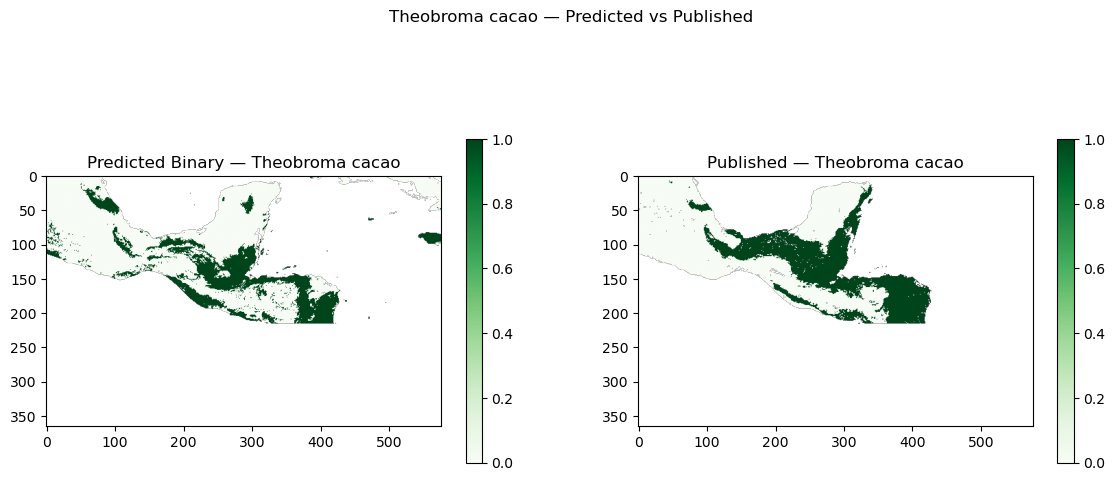

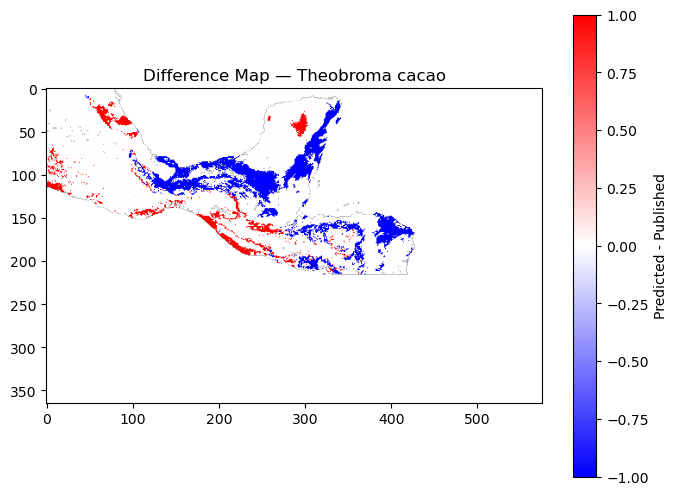

✅ Agreement (binary ≥ 0.2): 76.78%


In [80]:
def predict_and_plot_species(
    species,
    clf,
    feature_columns,
    bio_stack,
    lon_min=-100.98, lon_max=-77.02, lat_min=13, lat_max=21.98,
    published_path=None,
    threshold=0.2
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import rioxarray as rxr
    import xarray as xr

    # 🔷 Create prediction grid
    xv, yv = np.meshgrid(bio_stack.x.values, bio_stack.y.values)
    grid_df = pd.DataFrame({'lon': xv.ravel(), 'lat': yv.ravel()})

    for var in bio_stack.data_vars:
        grid_df[var] = bio_stack[var].values.ravel()

    # Drop NaNs & restrict to study area
    valid_grid_df = grid_df.dropna()
    valid_grid_df = valid_grid_df[
        (valid_grid_df['lon'] >= lon_min) & (valid_grid_df['lon'] <= lon_max) &
        (valid_grid_df['lat'] >= lat_min) & (valid_grid_df['lat'] <= lat_max)
    ]

    print(f"✅ Grid points in study area: {len(valid_grid_df)}")

    # 📈 Predict
    X_grid = valid_grid_df[feature_columns]
    suitability = clf.predict_proba(X_grid)[:, 1]

    # 🌏 Create grid array
    suitability_grid = np.full(bio_stack.BIO1.shape, np.nan)
    valid_mask = ~np.isnan(bio_stack.BIO1.values) & \
                 (xv >= lon_min) & (xv <= lon_max) & \
                 (yv >= lat_min) & (yv <= lat_max)
    suitability_grid[valid_mask] = suitability

    binary_suitability = np.full_like(suitability_grid, np.nan)
    binary_suitability[valid_mask] = (suitability >= threshold).astype(int)

    # 📄 Wrap as xarray
    binary_da = xr.DataArray(
        binary_suitability,
        dims=["y", "x"],
        coords={"y": bio_stack.y, "x": bio_stack.x},
        name="suitability"
    ).rio.write_crs("EPSG:4326")

    if published_path:
        # 📂 Load published map
        published = rxr.open_rasterio(published_path, masked=True).squeeze()
        published = published.rio.write_crs("EPSG:4326")

        unique_vals = np.unique(published.values[~np.isnan(published.values)])
        suspect_nodata = unique_vals[-1]
        if suspect_nodata >= 250:
            published_masked = published.where(published != suspect_nodata)
        else:
            published_masked = published

        binary_resampled = binary_da.rio.reproject_match(published)

        study_mask = (
            (published.x >= lon_min) & (published.x <= lon_max) &
            (published.y >= lat_min) & (published.y <= lat_max)
        )

        your_study = binary_resampled.where(study_mask, np.nan)
        published_study = published_masked.where(study_mask, np.nan)

        valid_overlap = ~np.isnan(your_study.values) & ~np.isnan(published_study.values)

        # 🗺️ Plot side-by-side
        fig, axs = plt.subplots(1, 2, figsize=(14,6))
        im0 = axs[0].imshow(your_study, cmap="Greens", origin="upper")
        axs[0].set_title(f"Predicted Binary — {species}")
        plt.colorbar(im0, ax=axs[0], shrink=0.7)

        im1 = axs[1].imshow(published_study, cmap="Greens", origin="upper")
        axs[1].set_title(f"Published — {species}")
        plt.colorbar(im1, ax=axs[1], shrink=0.7)

        plt.suptitle(f"{species} — Predicted vs Published")
        plt.show()

        # 🔷 Difference map
        diff = np.full_like(your_study.values, np.nan)
        diff[valid_overlap] = your_study.values[valid_overlap] - published_study.values[valid_overlap]

        plt.figure(figsize=(8,6))
        plt.imshow(diff, cmap="bwr", origin="upper")
        plt.colorbar(label="Predicted - Published")
        plt.title(f"Difference Map — {species}")
        plt.show()

        agreement = np.mean(
            your_study.values[valid_overlap] == published_study.values[valid_overlap]
        )
        print(f"✅ Agreement (binary ≥ {threshold}): {agreement*100:.2f}%")

    else:
        # Just plot prediction if no published map
        plt.figure(figsize=(10, 6))
        plt.pcolormesh(xv, yv, binary_suitability, cmap="Greens", shading='auto')
        plt.colorbar(label='Suitability')
        plt.title(f"Predicted Binary Suitability — {species}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

predict_and_plot_species(
    species="Theobroma cacao",
    clf=trained_classifiers["Theobroma cacao"],
    feature_columns=feature_columns["Theobroma cacao"],
    bio_stack=bio_stack,
    published_path="/Users/szelie/data/unu/suitability/THEOCA_baseline.tif"
)


✅ Grid points in study area: 48004


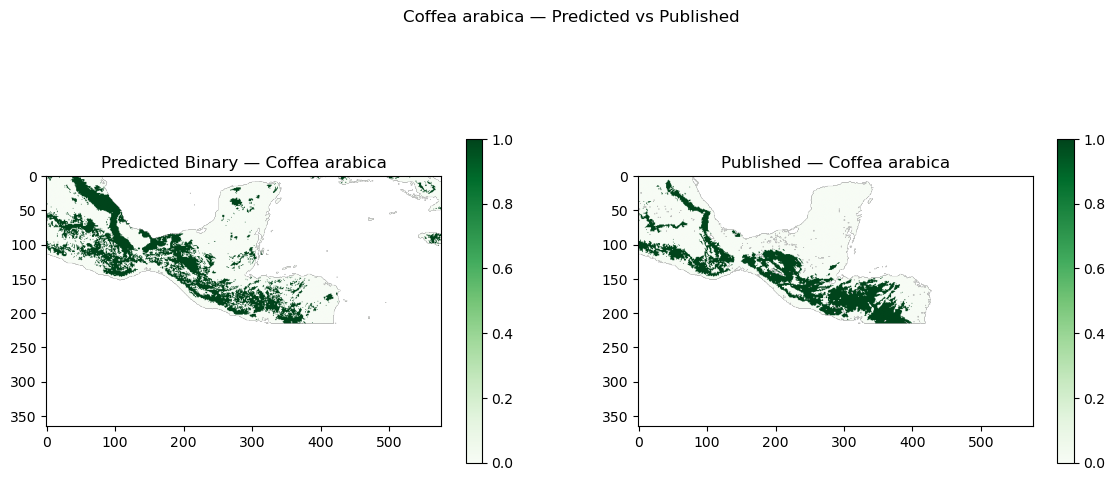

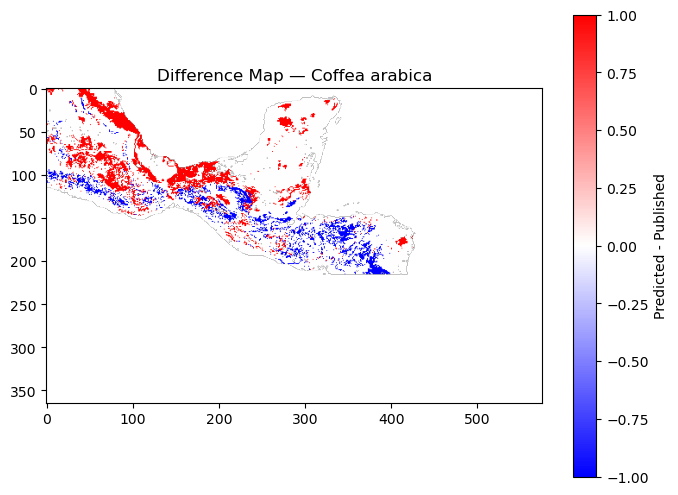

✅ Agreement (binary ≥ 0.2): 77.17%


In [79]:
predict_and_plot_species(
    species="Coffea arabica",
    clf=trained_classifiers["Coffea arabica"],
    feature_columns=feature_columns["Coffea arabica"],
    bio_stack=bio_stack,
    published_path="/Users/szelie/data/unu/suitability/COFFAR_baseline.tif"
)

In [19]:
# 📋 Get coordinates
lon_min = float(published.x.min())
lon_max = float(published.x.max())
lat_min = float(published.y.min())
lat_max = float(published.y.max())

print(f"🌎 Published map bounding box:")
print(f"Longitude: {lon_min:.2f} to {lon_max:.2f}")
print(f"Latitude:  {lat_min:.2f} to {lat_max:.2f}")

🌎 Published map bounding box:
Longitude: -100.98 to -77.02
Latitude:  6.81 to 21.98


In [57]:
# 📂 Save all presence points for MaxEnt
output_path = "/Users/szelie/data/unu/all_species_presence_maxent.csv"

# Filter only presence points (presence == 1)
presence_only = data_all[data_all["presence"] == 1][["species", "lon", "lat"]].copy()

# Save as CSV
presence_only.to_csv(output_path, index=False)

print(f"✅ Saved {len(presence_only)} presence records (all species) to:\n{output_path}")
print(presence_only.head())


✅ Saved 1245 presence records (all species) to:
/Users/szelie/data/unu/all_species_presence_maxent.csv
            species        lon        lat
0  Mangifera indica -88.563708  18.074789
1  Mangifera indica -88.562892  18.073619
2  Mangifera indica -89.200853  20.876713
3  Mangifera indica -88.667117  17.106394
4  Mangifera indica -86.572840  16.323948


In [58]:
presence_only.species.unique()

array(['Mangifera indica', 'Senna spectabilis', 'Theobroma cacao',
       'Coffea arabica'], dtype=object)

## Running MaxEnt for Species Distribution Modelling

In this step, we use **MaxEnt (Maximum Entropy Modelling)** to estimate species distribution (suitability) based on presence-only observations.  
MaxEnt is widely used because it performs well when only **presence data** is available (unlike Random Forest or logistic regression which also require absence/background data).  

MaxEnt works by finding the probability distribution of species occurrence over the study area that is closest to uniform (maximum entropy),  
while still being constrained to match the observed environmental conditions at the known presence points.  

Here we:
- Save a CSV file containing all **presence points** (for all species) with their coordinates and species names.
- Run the `maxent.jar` Java program, which uses the WorldClim bioclimatic variables and the presence points to produce suitability maps for each species.
- Use a random 25% of the points as a testing set (optional) and output the results in a dedicated folder.

This method is especially useful when no reliable absence data exists, and is one of the standard tools in ecological niche modelling.


In [65]:
import pandas as pd
import subprocess
import os

# 📋 Paths & filenames
maxent_jar = "/Users/szelie/maxent.jar"
env_layers_dir = "/Users/szelie/data/unu/bioclim_asc_subset"
output_dir = "/Users/szelie/data/unu/maxent_output"
presence_csv = "/Users/szelie/data/unu/all_species_presence_maxent.csv"


print(f"✅ Saved {len(presence_only)} presence records (all species) to:\n{presence_csv}")

# 📂 Make sure output dir exists
os.makedirs(output_dir, exist_ok=True)

print(f"✅ Using MaxEnt at: {maxent_jar}")
print(f"✅ Using presence points: {presence_csv}")
print(f"✅ Using environmental layers: {env_layers_dir}")
print(f"✅ Output will be saved to: {output_dir}")

# 🚀 Run MaxEnt
cmd = [
    "java", "-mx512m", "-jar", maxent_jar,
    f"environmentallayers={env_layers_dir}",
    f"samplesfile={presence_csv}",
    f"outputdirectory={output_dir}",
    "autorun",
    "randomseed",
    "randomtestpoints=25",  # use 25% of presence points for testing
    "replicates=1",
    "threads=2",
    "redoifexists"
]

print("🚀 Running MaxEnt …")
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    print(f"🎉 MaxEnt finished successfully! Outputs saved in:\n{output_dir}")
else:
    print(f"❌ MaxEnt failed. See error below:\n{result.stderr}")


✅ Saved 1245 presence records (all species) to:
/Users/szelie/data/unu/all_species_presence_maxent.csv
✅ Using MaxEnt at: /Users/szelie/maxent.jar
✅ Using presence points: /Users/szelie/data/unu/all_species_presence_maxent.csv
✅ Using environmental layers: /Users/szelie/data/unu/bioclim_asc_subset
✅ Output will be saved to: /Users/szelie/data/unu/maxent_output
🚀 Running MaxEnt …
🎉 MaxEnt finished successfully! Outputs saved in:
/Users/szelie/data/unu/maxent_output


In [60]:
import rioxarray as rxr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def plot_maxent_vs_published(species_name, maxent_path, published_path, threshold=0.2):
    """
    Plot and compare MaxEnt prediction for a species to the published suitability map.
    """
    # 📂 Load MaxEnt prediction
    maxent_pred = rxr.open_rasterio(maxent_path, masked=True).squeeze()
    maxent_pred = maxent_pred.rio.write_crs("EPSG:4326")  # adjust if needed

    # 📂 Load published map
    published = rxr.open_rasterio(published_path, masked=True).squeeze()
    published = published.rio.write_crs("EPSG:4326")

    # 🔷 Resample MaxEnt prediction to match published grid
    maxent_resampled = maxent_pred.rio.reproject_match(published)

    # 🔷 Threshold MaxEnt
    your_study_binary = xr.where(maxent_resampled >= threshold, 1, 0)

    # 🔷 Detect NoData
    published_masked = published.where(published < 250)

    # 🔷 Valid pixels
    valid_mask = ~np.isnan(your_study_binary.values) & ~np.isnan(published_masked.values)

    # 🗺️ Plot binary maps
    fig, axs = plt.subplots(1, 2, figsize=(14,6))

    im0 = axs[0].imshow(your_study_binary.values, cmap="Greens", origin="upper")
    axs[0].set_title(f"{species_name} — MaxEnt (≥ {threshold})")
    plt.colorbar(im0, ax=axs[0], shrink=0.7)

    im1 = axs[1].imshow(published_masked.values, cmap="Greens", origin="upper")
    axs[1].set_title(f"{species_name} — Published")
    plt.colorbar(im1, ax=axs[1], shrink=0.7)

    plt.suptitle(f"{species_name} — Binary Suitability Comparison")
    plt.show()

    # 🗺️ Difference map
    diff_binary = np.full_like(your_study_binary.values, np.nan)
    diff_binary[valid_mask] = your_study_binary.values[valid_mask] - published_masked.values[valid_mask]

    plt.figure(figsize=(8,6))
    plt.imshow(diff_binary, cmap="bwr", origin="upper")
    plt.colorbar(label="MaxEnt binary - Published")
    plt.title(f"{species_name} — Binary Difference Map")
    plt.show()

    # 📈 Agreement
    agreement = np.mean(
        your_study_binary.values[valid_mask] == published_masked.values[valid_mask]
    )

    print(f"✅ Agreement (binary, ≥ {threshold}): {agreement*100:.2f}%")



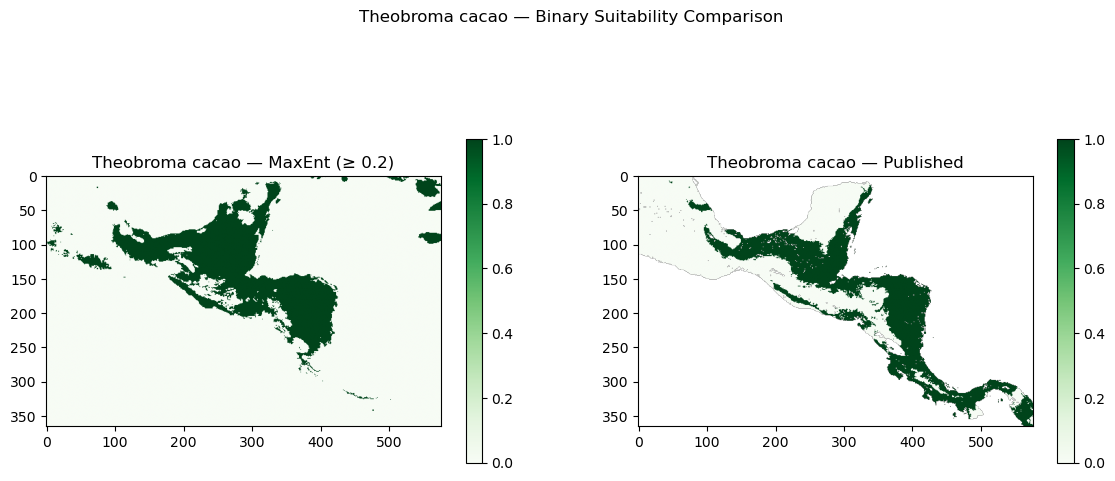

/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


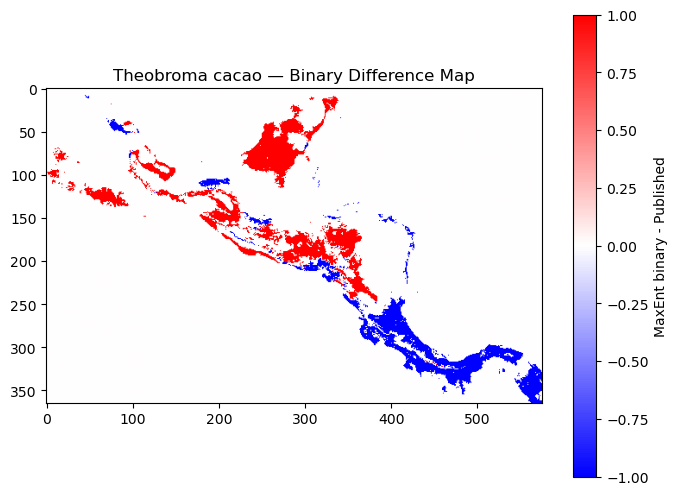

✅ Agreement (binary, ≥ 0.2): 69.24%


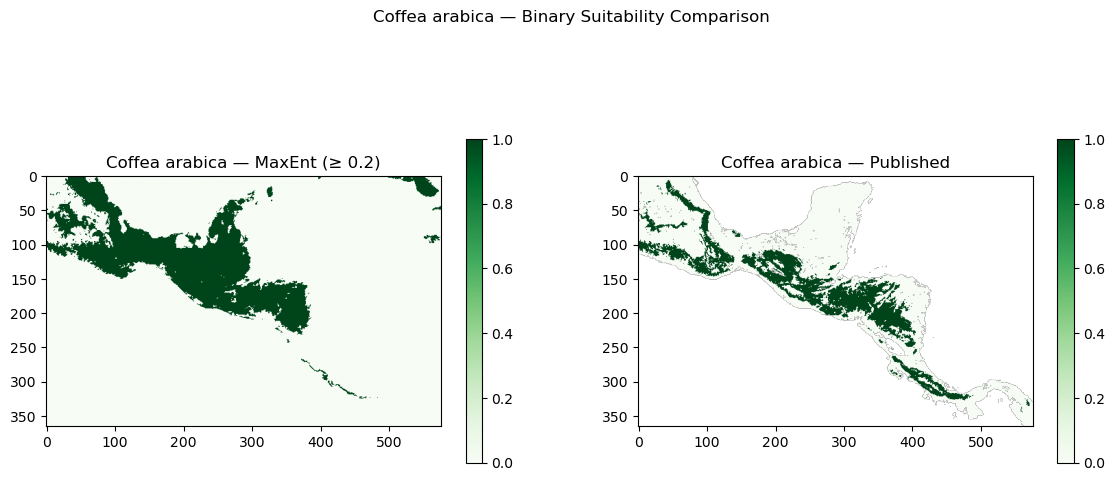

/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


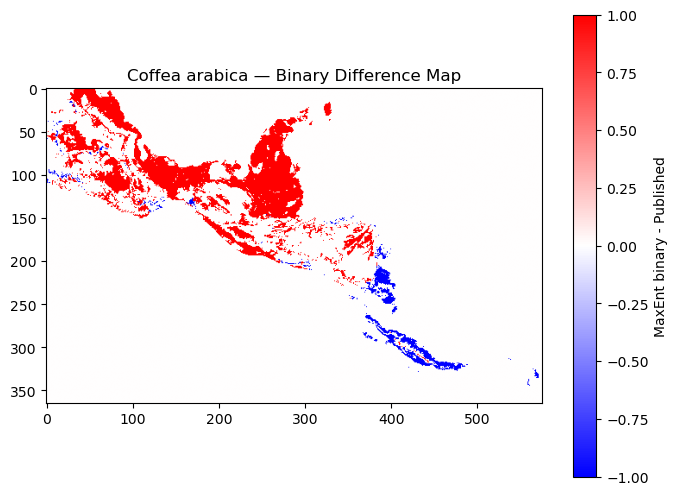

✅ Agreement (binary, ≥ 0.2): 66.88%


In [66]:
# Run for Theobroma cacao
plot_maxent_vs_published(
    species_name="Theobroma cacao",
    maxent_path="/Users/szelie/data/unu/maxent_output/Theobroma_cacao.asc",
    published_path="/Users/szelie/data/unu/suitability/THEOCA_baseline.tif",
    threshold=0.2
)

# Run for Coffea arabica
plot_maxent_vs_published(
    species_name="Coffea arabica",
    maxent_path="/Users/szelie/data/unu/maxent_output/Coffea_arabica.asc",
    published_path="/Users/szelie/data/unu/suitability/COFFAR_baseline.tif",
    threshold=0.2
)


In [68]:
import subprocess
import os

maxent_jar = "/Users/szelie/maxent.jar"
env_layers_dir = "/Users/szelie/data/unu/bioclim_asc_subset"
presence_csv = "/Users/szelie/data/unu/all_species_presence_maxent.csv"
output_dir = "/Users/szelie/data/unu/maxent_output"
projection_dir = "/Users/szelie/data/unu/bioclim_asc_projection_2050"

os.makedirs(output_dir, exist_ok=True)

cmd = [
    "java", "-mx512m", "-jar", maxent_jar,
    f"environmentallayers={env_layers_dir}",
    f"samplesfile={presence_csv}",
    f"outputdirectory={output_dir}",
    f"projectionlayers={projection_dir}",
    "autorun",
    "randomseed",
    "randomtestpoints=25",
    "replicates=1",
    "threads=2",
    "redoifexists"
]

print("🚀 Running MaxEnt with future projection …")
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    print(f"🎉 MaxEnt finished successfully! Outputs saved in:\n{output_dir}")
else:
    print(f"❌ MaxEnt failed:\n{result.stderr}")


🚀 Running MaxEnt with future projection …
🎉 MaxEnt finished successfully! Outputs saved in:
/Users/szelie/data/unu/maxent_output


✅ Min change: -0.651
✅ Max change: 0.200


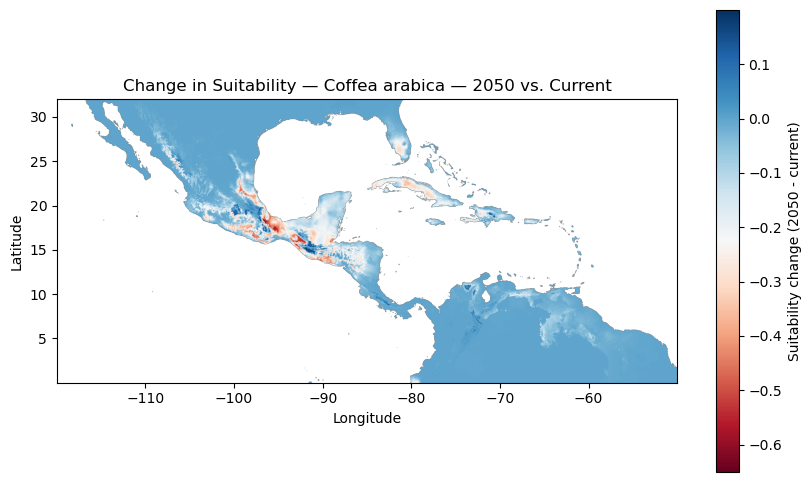

In [73]:
import rioxarray as rxr
import matplotlib.pyplot as plt
import numpy as np

# 📂 Paths
current_path = "/Users/szelie/data/unu/maxent_output/Coffea_arabica.asc"
future_path = "/Users/szelie/data/unu/maxent_output/Coffea_arabica_bioclim_asc_projection_2050.asc"

# 📋 Load current suitability
current = rxr.open_rasterio(current_path, masked=True).squeeze()
current = current.rio.write_crs("EPSG:4326")  # optional

# 📋 Load future suitability
future = rxr.open_rasterio(future_path, masked=True).squeeze()
future = future.rio.write_crs("EPSG:4326")  # optional

# 🔷 Align/resample future to current grid if needed
if future.shape != current.shape or not np.allclose(future.x, current.x) or not np.allclose(future.y, current.y):
    future = future.rio.reproject_match(current)

# 🔷 Compute difference
change = future - current

print(f"✅ Min change: {np.nanmin(change.values):.3f}")
print(f"✅ Max change: {np.nanmax(change.values):.3f}")

# 🗺️ Plot change
plt.figure(figsize=(10, 6))
im = plt.imshow(change.values, cmap="RdBu", extent=[
    change.x.min(), change.x.max(), change.y.min(), change.y.max()
], origin="upper")
plt.colorbar(im, label="Suitability change (2050 - current)")
plt.title("Change in Suitability — Coffea arabica — 2050 vs. Current")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
